In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def lin_interpolate(x0,x1,y0,y1,x):
    return y0 + ((y1-y0)/(x1-x0))*(x-x0)

In [3]:
def quad_interpolate(x0,x1,x2,y0,y1,y2,x):
    return y0*((x-x1)*(x-x2))/((x0-x1)*(x0-x2)) + y1*((x-x0)*(x-x2))/((x1-x0)*(x1-x2)) + y2*((x-x1)*(x-x0))/((x2-x1)*(x2-x0))

In [4]:
def poly_n_interpolate(xn,yn,x):
    pn = 0
    n = len(xn)

    for i in range(n):
        l_i = 1
        for j in range(n):
            if i != j:
                l_i *= (x-xn[j])/(xn[i]-xn[j])
        pn += yn[i]*l_i

    return pn

In [5]:
def newton_interpolate(xn,yn,x):
    n = len(xn)
    slopes = yn.copy()

    for i in range(1,n):
        for j in range(n-1,i-1,-1):
            slopes[j] = (slopes[j]-slopes[j-1])/(xn[j]-xn[j-i])

    pn = slopes[0]
    term = 1
    for i in range(1,n):
        term *= x-xn[i-1]
        pn += slopes[i]*term

    return pn

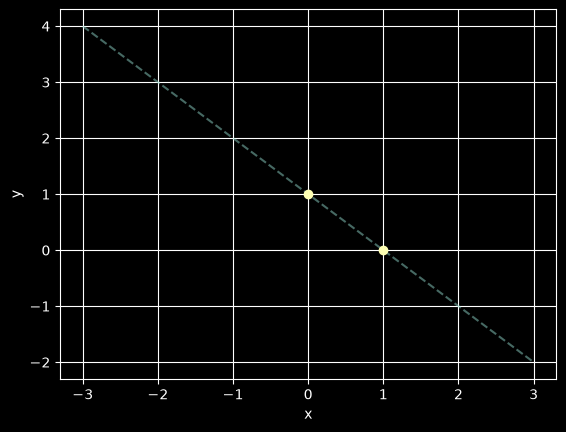

In [6]:
x0 = 0
y0 = 1
x1 = 1
y1 = 0

x_range = np.linspace(-3,3,100)
y_range = []
for i in x_range:
    y_range.append(lin_interpolate(x0,x1,y0,y1,i))

plt.plot(x_range, y_range, linestyle='--', alpha=0.5)
plt.plot([x0,x1],[y0,y1], marker='o', linestyle='None')
plt.xlabel('x')
plt.ylabel('y')

plt.grid(True)

plt.show()

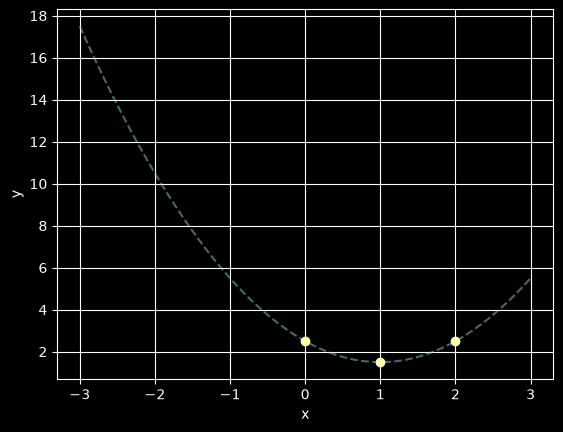

In [7]:
x0 = 0
y0 = 2.5
x1 = 1
y1 = 1.5
x2 = 2
y2 = 2.5

x_range = np.linspace(-3,3,100)
y_range = []
for i in x_range:
    y_range.append(quad_interpolate(x0,x1,x2,y0,y1,y2,i))

plt.plot(x_range, y_range, linestyle='--', alpha=0.5)
plt.plot([x0,x1,x2],[y0,y1,y2], marker='o', linestyle='None')
plt.xlabel('x')
plt.ylabel('y')

plt.grid(True)

plt.show()

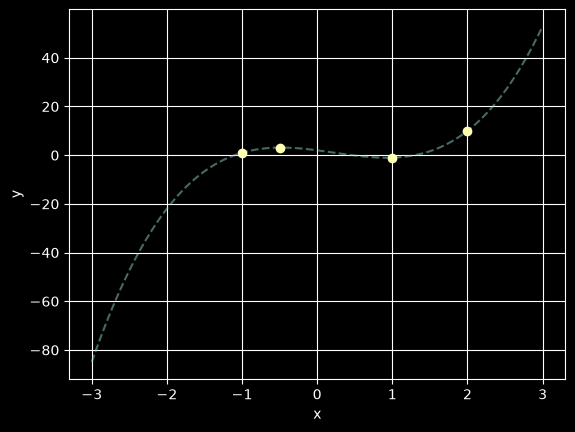

In [8]:
xn = [-1,-0.5,1,2]
yn = [1,3.125,-1,10]

x_range = np.linspace(-3,3,100)
y_range = []
for i in x_range:
    y_range.append(poly_n_interpolate(xn,yn,i))

plt.plot(x_range, y_range, linestyle='--', alpha=0.5)
plt.plot(xn, yn, marker='o', linestyle='None')
plt.xlabel('x')
plt.ylabel('y')

plt.grid(True)

plt.show()

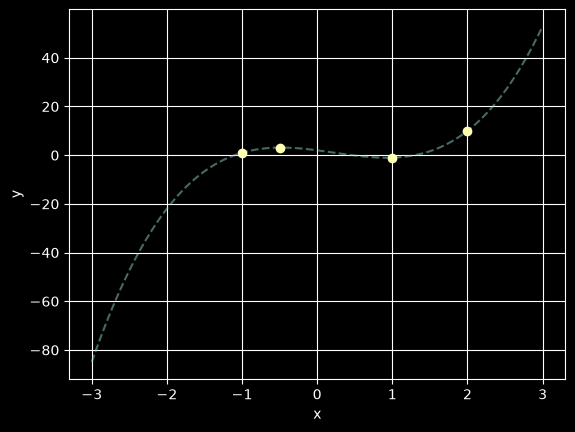

In [9]:
xn = [-1,-0.5,1,2]
yn = [1,3.125,-1,10]

x_range = np.linspace(-3,3,100)
y_range = []
for i in x_range:
    y_range.append(newton_interpolate(xn,yn,i))

plt.plot(x_range, y_range, linestyle='--', alpha=0.5)
plt.plot(xn, yn, marker='o', linestyle='None')
plt.xlabel('x')
plt.ylabel('y')

plt.grid(True)

plt.show()